# 1. Introduction

Interest rates play a central role in financial markets, influencing the pricing of bonds, derivatives, loans, and a wide range of investment decisions. Since interest rates evolve continuously over time and are affected by numerous economic factors, accurately modeling their behavior has long been an important problem in quantitative finance.

One of the most widely studied approaches for modeling interest rate dynamics is the class of short-rate models, which describe the evolution of the instantaneous interest rate using stochastic processes. Among these models, the Cox-Ingersoll-Ross (CIR) model is particularly significant because it incorporates mean reversion while ensuring that interest rates remain non-negative under appropriate conditions. These properties make it both mathematically appealing and practically relevant for fixed-income valuation and risk management.

The objective of this project is to implement, calibrate, and evaluate the CIR model using historical yield curve data. The model parameters are estimated from observed market data, after which the calibrated model is used to reconstruct the yield curve using only the 3-Month yield as a proxy for the short-term interest rate. The reconstructed yields are then compared against actual market observations to assess the model's predictive capability.

While the CIR model provides a tractable framework for interest rate modeling, it also has several limitations, including its inability to perfectly fit arbitrary yield curve shapes and its restricted flexibility during changing market conditions. To address these shortcomings, this project further explores an extension of the base model and evaluates whether the additional complexity leads to improved out-of-sample performance.

The project follows a complete quantitative modeling workflow consisting of data preprocessing, exploratory data analysis, parameter calibration, yield curve reconstruction, model evaluation, and critical analysis. The ultimate goal is not only to assess the predictive performance of the CIR framework but also to understand its strengths, limitations, and practical applicability in real-world financial modeling.


# 2. Dataset Description

The dataset used in this project consists of historical zero-coupon yield observations across multiple maturities. The data is divided into a training set, which is used for model calibration, and a test set, which is used for out-of-sample evaluation.

Each row represents a single observation date, while each column corresponds to a specific maturity on the yield curve. The maturities included in the dataset span from short-term to long-term horizons, allowing the complete term structure of interest rates to be analyzed.

| Column Name | Maturity |
| ----------- | -------- |
| ZC025YR     | 3 Months |
| ZC050YR     | 6 Months |
| ZC075YR     | 9 Months |
| ZC100YR     | 1 Year   |
| ZC200YR     | 2 Years  |
| ZC500YR     | 5 Years  |
| ZC1000YR    | 10 Years |
| ZC2000YR    | 20 Years |
| ZC3000YR    | 30 Years |

The training dataset contains 1,976 observations covering all nine maturities. The test dataset contains the 3-Month yield along with selected target maturities that are used to evaluate the predictive performance of the calibrated model.

A key requirement of this project is that, during the prediction phase, only the 3-Month yield is permitted as an input. This yield acts as a proxy for the instantaneous short rate in the CIR framework. Using the calibrated model parameters and the observed 3-Month yield, the remaining points on the yield curve are reconstructed and compared against the actual observed yields.

Before model development, the dataset is examined for consistency, missing values, outliers, and general statistical properties. Understanding the structure and behavior of the data is an essential step in determining whether the assumptions of the CIR model are reasonable for the given market environment.


In [22]:
import pandas as pd

train_df = pd.read_csv(
    "https://raw.githubusercontent.com/Grivann/FinClubPS1/main/train_data.csv"
)

test_df = pd.read_csv(
    "https://raw.githubusercontent.com/Grivann/FinClubPS1/main/test_data.csv"
)

test_3m_df = pd.read_csv(
    "https://raw.githubusercontent.com/Grivann/FinClubPS1/main/test_data_3M.csv"
)

train_df['Date'] = pd.to_datetime(train_df['Date'])
test_df['Date'] = pd.to_datetime(test_df['Date'])
test_3m_df['Date'] = pd.to_datetime(test_3m_df['Date'])

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)
print("Test 3M Shape:", test_3m_df.shape)

train_df.head()

Train Shape: (1976, 10)
Test Shape: (495, 6)
Test 3M Shape: (495, 2)


,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
3,2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
4,2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591


## Data Cleaning

Before proceeding with model development, the dataset was inspected for missing values, duplicate records, inconsistent data types, and potential outliers. Since financial models are highly sensitive to data quality, ensuring the integrity of the yield observations is an important prerequisite for reliable parameter estimation and forecasting.

The following checks were performed:

- Missing value analysis
- Duplicate row detection
- Data type verification
- Summary statistics inspection
- Outlier identification using boxplots

Any issues identified during this stage would be addressed before moving to exploratory analysis and model calibration.

Training Data Shape: (1976, 10)

Data Types:
Date         datetime64[ns]
 ZC025YR            float64
 ZC050YR            float64
 ZC075YR            float64
 ZC100YR            float64
 ZC200YR            float64
 ZC500YR            float64
 ZC1000YR           float64
 ZC2000YR           float64
 ZC3000YR           float64
dtype: object

Missing Values:
Date         0
 ZC025YR     0
 ZC050YR     0
 ZC075YR     0
 ZC100YR     0
 ZC200YR     0
 ZC500YR     0
 ZC1000YR    0
 ZC2000YR    0
 ZC3000YR    0
dtype: int64

Duplicate Rows:
0
Minimum Yield in Dataset: 0.0004864
Maximum Yield in Dataset: 0.0549405


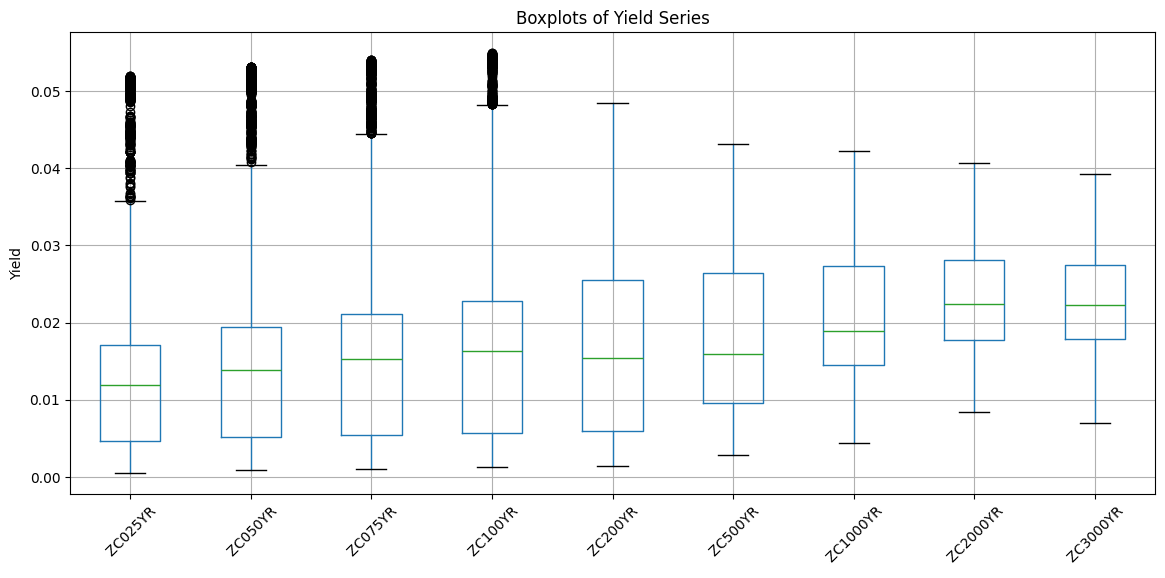

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Training Data Shape:", train_df.shape)
print("\nData Types:")
print(train_df.dtypes)

print("\nMissing Values:")
print(train_df.isnull().sum())

print("\nDuplicate Rows:")
print(train_df.duplicated().sum())

train_df.describe().T

# Check for impossible values
print("Minimum Yield in Dataset:", train_df.iloc[:,1:].min().min())
print("Maximum Yield in Dataset:", train_df.iloc[:,1:].max().max())

# plt.figure(figsize=(10,4))
# sns.heatmap(train_df.isnull(), cbar=False)
# plt.title("Missing Value Heatmap")
# plt.show()



plt.figure(figsize=(14,6))
train_df.boxplot(rot=45)
plt.title("Boxplots of Yield Series")
plt.ylabel("Yield")
plt.show()

### Data Cleaning Summary

The dataset was found to be well-structured and free from missing values or duplicate observations. All columns contained numerical yield data suitable for quantitative analysis. All yields are positive and fall within a realistic range, consistent with the assumptions of the CIR framework.

The boxplots reveal a general increase in median yields as maturity increases, indicating the presence of a predominantly upward-sloping term structure. Short-term maturities exhibit a larger number of outliers, reflecting periods of elevated short-term interest rates caused by changing market conditions. Since these observations are economically meaningful rather than data-entry errors, they were retained in the analysis.

The yield distributions remain positive and exhibit no abnormal patterns, suggesting that the dataset is suitable for calibration of the CIR model without additional preprocessing.

Since the dataset already satisfied the requirements for model calibration, no additional preprocessing was necessary beyond validation and exploratory inspection.

## Exploratory Data Analysis

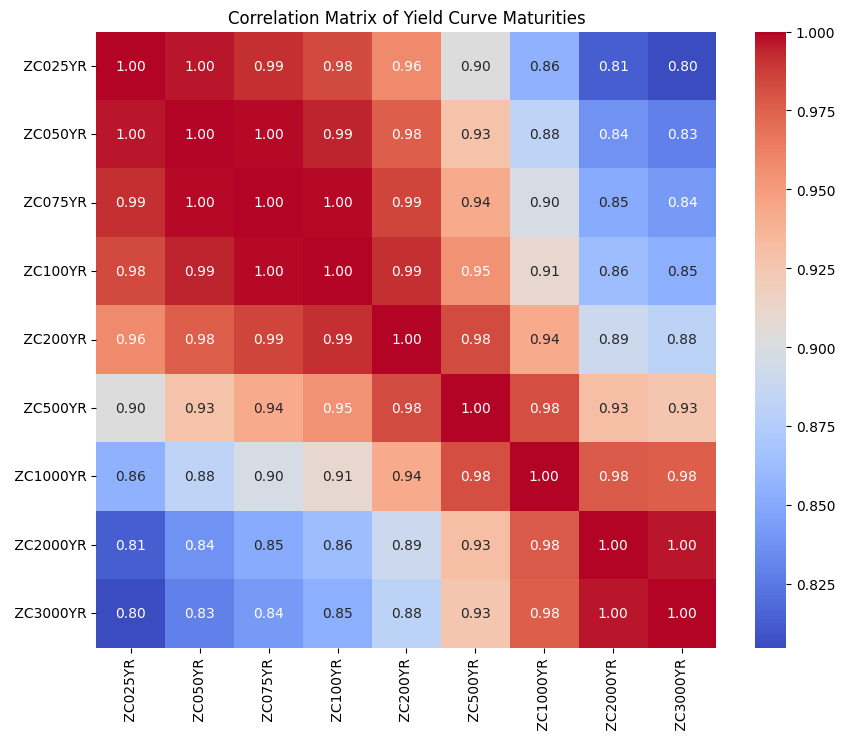

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = train_df.iloc[:,1:].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Yield Curve Maturities")
plt.show()

In [25]:
corr_3m = train_df.iloc[:,1:].corr()[' ZC025YR']
display(corr_3m.sort_values(ascending=False))

,ZC025YR
ZC025YR,1.000000
ZC050YR,0.996753
ZC075YR,0.991606
ZC100YR,0.983699
ZC200YR,0.958671
ZC500YR,0.902963
ZC1000YR,0.855762
ZC2000YR,0.812972
ZC3000YR,0.804896


Correlation decreases gradually from 1.00 for nearby maturities to approximately 0.80 for the 30-year tenor.

### Correlation Analysis

The correlation matrix reveals strong positive relationships across all maturities. Adjacent maturities exhibit particularly high correlations, while correlations gradually decline as the maturity gap increases.

The strong relationship between the 3-Month yield and longer maturities suggests that a significant portion of the yield curve dynamics can be explained by a common underlying factor. This observation supports the use of the short rate as the primary input in the CIR framework.

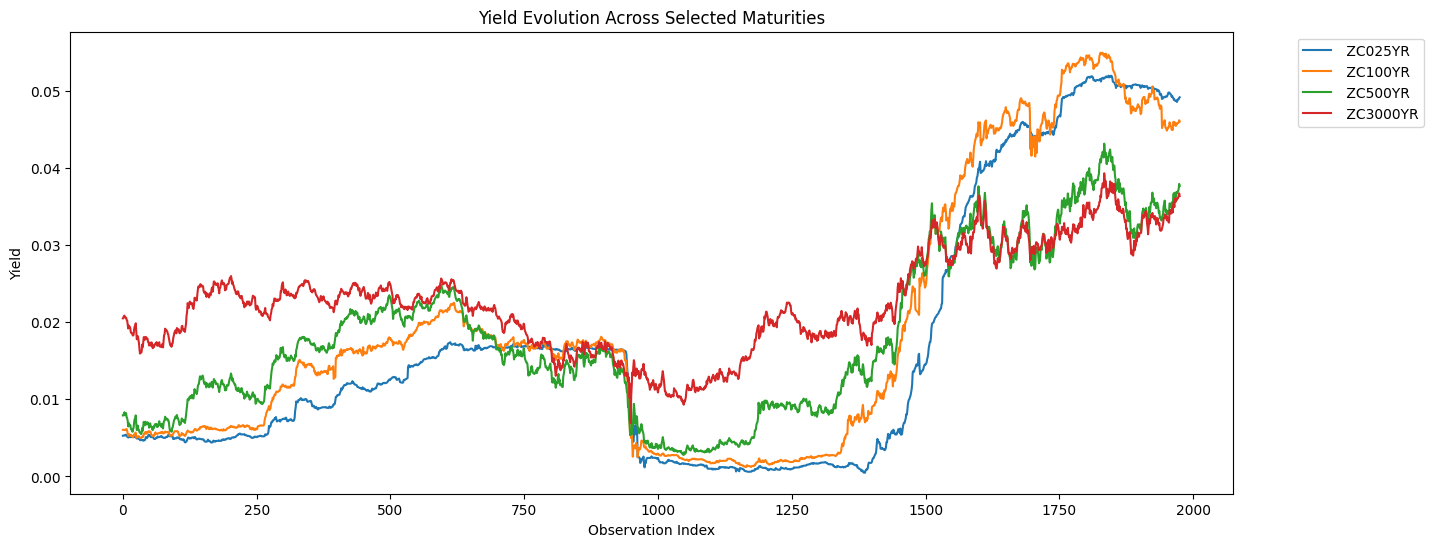

In [27]:
plt.figure(figsize=(15,6))

selected_cols = [
    ' ZC025YR',
    ' ZC100YR',
    ' ZC500YR',
    ' ZC3000YR'
]

for col in selected_cols:
    plt.plot(train_df[col], label=col)

plt.title("Yield Evolution Across Selected Maturities")
plt.xlabel("Observation Index")
plt.ylabel("Yield")
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

### Yield Evolution

The yield series move together over time, indicating the presence of common underlying drivers affecting the entire term structure. While the magnitudes differ across maturities, the overall trends remain similar, suggesting strong co-movement throughout the yield curve.

This behavior supports the assumptions of factor-based interest rate models such as CIR.

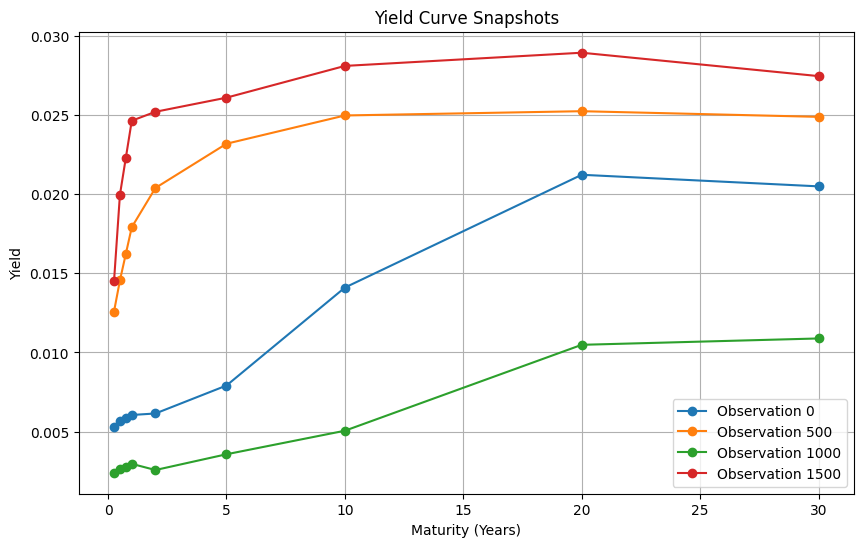

In [28]:
maturities = [0.25,0.5,0.75,1,2,5,10,20,30]

rows = [0,500,1000,1500]

plt.figure(figsize=(10,6))

for row in rows:
    plt.plot(
        maturities,
        train_df.iloc[row,1:],
        marker='o',
        label=f'Observation {row}'
    )

plt.xlabel("Maturity (Years)")
plt.ylabel("Yield")
plt.title("Yield Curve Snapshots")
plt.legend()
plt.grid(True)
plt.show()

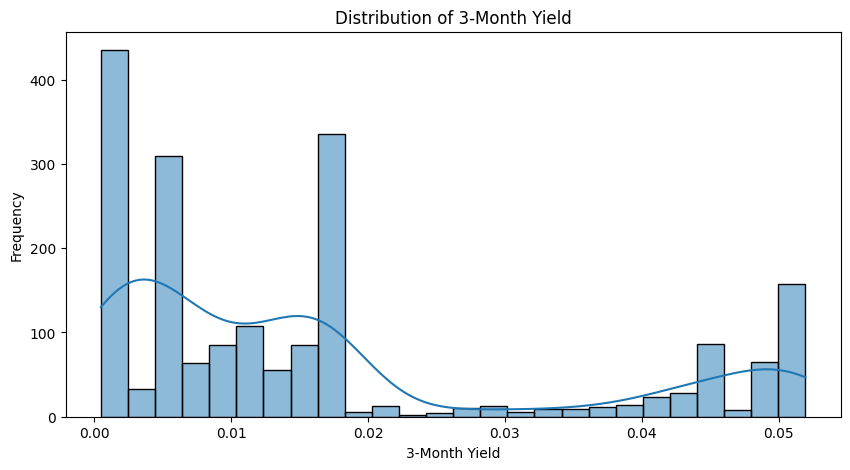

In [29]:
plt.figure(figsize=(10,5))
sns.histplot(train_df[' ZC025YR'], kde=True)
plt.title("Distribution of 3-Month Yield")
plt.xlabel("3-Month Yield")
plt.ylabel("Frequency")
plt.show()

The short rate exhibits a positively skewed distribution with rates concentrated in lower ranges.

### Yield Curve Snapshots

Yield curves sampled from different points in time exhibit varying shapes and levels. While many observations display a traditional upward-sloping structure, the slope and curvature of the term structure change over time.

These variations highlight the challenges associated with accurately modeling the entire yield curve using a single-factor framework and motivate the need for model extensions.

## EDA Summary

Three key observations emerge from the exploratory analysis:

1. Strong positive correlations exist across all maturities, indicating that movements in the yield curve are largely driven by common underlying factors.

2. Yield series exhibit substantial co-movement through time, suggesting that changes in market conditions affect the entire term structure simultaneously.

3. Yield curve snapshots show predominantly upward-sloping and smooth term structures, although the overall level and shape vary across different periods.

These findings support the use of the 3-Month yield as a proxy for the short rate and provide motivation for applying the CIR framework to reconstruct the remaining maturities.

## CIR Theory

# Cox-Ingersoll-Ross (CIR) Model

The CIR model assumes that the short-term interest rate follows a mean-reverting stochastic process:

$$
dr_t = \kappa(\theta-r_t)dt + \sigma\sqrt{r_t}dW_t
$$

where:

- $\kappa$ : speed of mean reversion
- $\theta$ : long-run mean interest rate
- $\sigma$ : volatility parameter
- $W_t$ : standard Brownian motion

The square-root diffusion term ensures that interest rates remain positive under suitable parameter conditions. The model satisfies the Feller condition:

$$
2\kappa\theta \geq \sigma^2
$$

which prevents the short rate from reaching negative values.

## Why the 3-Month Yield is Used as the Short Rate

The CIR model is a short-rate model and requires observations of the instantaneous short rate. Since the true instantaneous rate is not directly observable, the 3-Month yield is used as a practical proxy. The strong correlations observed during exploratory analysis further support this approximation.

In [30]:
# Code for CIR Theory

## CIR Calibration

In [31]:
# Code for CIR Calibration

## Yield Curve Reconstruction

In [32]:
# Code for Yield Curve Reconstruction

## Model Evaluation

In [33]:
# Code for Model Evaluation

## CIR++ Extension

In [34]:
# Code for CIR++ Extension

## Model Comparison

In [35]:
# Code for Model Comparison

## Limitations

In [36]:
# Code for Limitations

## Conclusion

In [37]:
# Code for Conclusion